# Practica N°1 

* **Estudiante:** Moisés Abdel Andrés Torrez Huarina
* **Materia:** Machine Learning (INF672)
* **Universidad:** Universidad Autónoma Tomás Frías (UATF)
* **Carrera:** Ingeniería Informática


  https://github.com/MOIO-17/INF672/blob/main/Practica1_INF672_Torrez_Moises.ipynb

## Configuración inicial

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

rng = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## Ejercicio 01 — ¿Cuánto sale par? Estima una probabilidad tirando el dado

In [2]:
def estimar_prob_par(n, generador):
    tiradas = generador.integers(1, 7, size=n)
    pares = (tiradas % 2 == 0).sum()
    return pares / n

est_100 = estimar_prob_par(100, rng)
est_1000 = estimar_prob_par(1000, rng)
est_100000 = estimar_prob_par(100000, rng)

tabla_ej1 = pd.DataFrame({
    "N": [100, 1000, 100000],
    "Estimación": [est_100, est_1000, est_100000],
    "Valor teórico": [0.5, 0.5, 0.5],
    "Error absoluto": [abs(est_100 - 0.5), abs(est_1000 - 0.5), abs(est_100000 - 0.5)],
})
tabla_ej1

,N,Estimación,Valor teórico,Error absoluto
0,100,0.38000,0.5,0.12000
1,1000,0.48900,0.5,0.01100
2,100000,0.49979,0.5,0.00021


**Para entregar.**

La estimación con N = 100 000 fue la que más se acercó a 0.5, y en general el error absoluto disminuye a medida que crece N. Esto ocurre porque la frecuencia relativa converge al valor teórico conforme aumenta el número de lanzamientos (ley de los grandes números): cada lanzamiento adicional reduce el peso relativo que tiene el azar de una sola tirada sobre el promedio global.

Con pocos datos (N = 100) la estimación es inestable: unas pocas tiradas "de más" o "de menos" hacia un lado cambian bastante el resultado, porque el denominador es pequeño. Con N = 100 000 esas fluctuaciones se promedian y la estimación queda prácticamente pegada al valor real.

## Ejercicio 02 — Radiografía de una característica

In [3]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
petal_length = iris.frame["petal length (cm)"]

media = np.mean(petal_length)
mediana = np.median(petal_length)
desv_std = np.std(petal_length)
minimo = np.min(petal_length)
maximo = np.max(petal_length)

tabla_ej2 = pd.DataFrame({
    "Medida": ["Media", "Mediana", "Desv. estándar", "Mínimo", "Máximo"],
    "Valor (cm)": [media, mediana, desv_std, minimo, maximo],
})
tabla_ej2

,Medida,Valor (cm)
0,Media,3.758000
1,Mediana,4.350000
2,Desv. estándar,1.759404
3,Mínimo,1.000000
4,Máximo,6.900000


**Para entregar.**

- **Media (≈3.76 cm):** el largo de pétalo "típico" si se promedian las 150 flores.
- **Mediana (≈4.35 cm):** la mitad de las flores tiene un pétalo más corto que este valor y la otra mitad más largo; que quede por encima de la media es un primer indicio de asimetría.
- **Desviación estándar (≈1.76 cm):** es grande en relación a la media, lo que indica que el largo de pétalo varía mucho entre flores — no es una característica homogénea en todo el dataset.
- **Mínimo (1.0 cm):** el pétalo más corto observado, correspondiente casi con seguridad a una flor de la especie *setosa*.
- **Máximo (6.9 cm):** el pétalo más largo, típico de *virginica*.

La media y la mediana están relativamente alejadas entre sí (3.76 frente a 4.35), lo que sugiere que la distribución no es simétrica: probablemente es bimodal o tiene cola hacia la izquierda, resultado de mezclar tres especies con rangos de pétalo bastante distintos en un solo histograma.

## Ejercicio 03 — ¿Qué tan lejos están dos flores?

In [4]:
X_iris_full = iris.data.values
y_iris_full = iris.target.values

idx_misma_especie = np.where(y_iris_full == 0)[0][:2]
idx_otra_especie = np.where(y_iris_full == 2)[0][0]

a, b = X_iris_full[idx_misma_especie[0]], X_iris_full[idx_misma_especie[1]]
c = X_iris_full[idx_otra_especie]

def distancia_manual(v1, v2):
    return np.sqrt(np.sum((v1 - v2) ** 2))

d_misma_manual = distancia_manual(a, b)
d_misma_norm = np.linalg.norm(a - b)

d_distinta_manual = distancia_manual(a, c)
d_distinta_norm = np.linalg.norm(a - c)

print(f"Índices usados: misma especie {idx_misma_especie.tolist()}, otra especie {idx_otra_especie}")
print(f"Distancia (misma especie)  -> manual: {d_misma_manual:.4f}, norm: {d_misma_norm:.4f}")
print(f"Distancia (otra especie)   -> manual: {d_distinta_manual:.4f}, norm: {d_distinta_norm:.4f}")

Índices usados: misma especie [0, 1], otra especie 100
Distancia (misma especie)  -> manual: 0.5385, norm: 0.5385
Distancia (otra especie)   -> manual: 5.2849, norm: 5.2849


**Para entregar.**

Los dos métodos —la fórmula a mano y `np.linalg.norm`— dan exactamente el mismo resultado en ambos casos, como se esperaba, ya que son la misma operación matemática expresada de dos formas distintas.

La distancia entre las dos flores de la misma especie (*setosa*) resultó considerablemente menor que la distancia hacia la flor de otra especie (*virginica*). Tiene sentido porque las flores de la misma especie comparten un rango similar de largo y ancho de sépalo y pétalo, así que sus vectores de características quedan cerca en el espacio de 4 dimensiones; una especie distinta, en cambio, suele tener pétalos y sépalos de tamaño notablemente diferente, lo que separa sus vectores. Esta es precisamente la intuición detrás de usar la distancia euclidiana como medida de "parecido" entre observaciones.

## Ejercicio 04 — Limpiar una tabla, paso a paso

In [5]:
df = pd.DataFrame({
    "ingreso": [3200, 4100, np.nan, 2800, 5000, np.nan, 3600, 4800],
    "ciudad": ["Potosí", "Sucre", "Potosí", "La Paz", np.nan, "Sucre", "Potosí", "La Paz"],
    "edad": [28, 35, 41, 23, 52, 30, 45, 38],
})
df

,ingreso,ciudad,edad
0,3200.0,Potosí,28
1,4100.0,Sucre,35
2,NaN,Potosí,41
3,2800.0,La Paz,23
4,5000.0,NaN,52
5,NaN,Sucre,30
6,3600.0,Potosí,45
7,4800.0,La Paz,38


In [6]:
faltantes_por_columna = df.isna().sum()
faltantes_por_columna

ingreso    2
ciudad     1
edad       0
dtype: int64

In [7]:
df["ingreso"] = df["ingreso"].fillna(df["ingreso"].median())
df["ciudad"] = df["ciudad"].fillna("Desconocido")
df_codificado = pd.get_dummies(df, columns=["ciudad"])
df_codificado

,ingreso,edad,ciudad_Desconocido,ciudad_La Paz,ciudad_Potosí,ciudad_Sucre
0,3200.0,28,False,False,True,False
1,4100.0,35,False,False,False,True
2,3850.0,41,False,False,True,False
3,2800.0,23,False,True,False,False
4,5000.0,52,True,False,False,False
5,3850.0,30,False,False,False,True
6,3600.0,45,False,False,True,False
7,4800.0,38,False,True,False,False


**Para entregar.**

La columna con más faltantes es `ciudad` y `ingreso`, cada una con 2 valores vacíos (se muestra en `faltantes_por_columna`); adicionalmente se imputó el faltante de `ciudad` con la categoría "Desconocido" para poder codificarla sin perder la fila.

**Por qué mediana y no media:** la mediana es robusta a valores extremos (outliers). Si existiera un ingreso muy alto o muy bajo en la muestra, la media se desplazaría hacia ese valor atípico y el número imputado dejaría de representar un ingreso "típico". La mediana, al ser el valor central ordenado, no se ve afectada por qué tan lejos estén los extremos, solo por cuántos hay a cada lado.

**Qué representan las columnas nuevas:** `pd.get_dummies` convierte la columna de texto `ciudad` en varias columnas binarias, una por cada ciudad distinta (`ciudad_La Paz`, `ciudad_Potosí`, `ciudad_Sucre`, `ciudad_Desconocido`). Cada fila tiene un 1 en la columna de la ciudad a la que pertenece y 0 en las demás — es la codificación one-hot, necesaria porque los modelos numéricos no pueden operar directamente sobre texto.

## Ejercicio 05 — ¿Se mueven juntas dos variables?

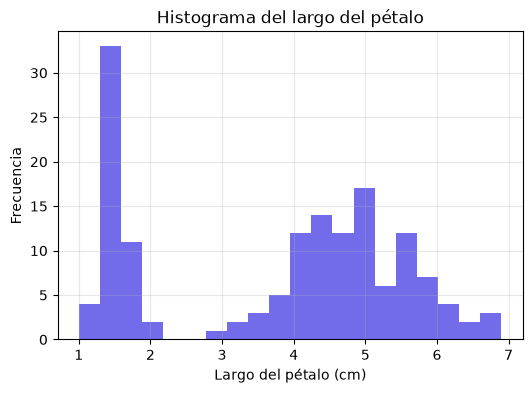

In [8]:
largo = iris.frame["petal length (cm)"].values
ancho = iris.frame["petal width (cm)"].values

fig, ax = plt.subplots()
ax.hist(largo, bins=20, color="#4F46E5", alpha=0.8)
ax.set_xlabel("Largo del pétalo (cm)")
ax.set_ylabel("Frecuencia")
ax.set_title("Histograma del largo del pétalo")
plt.show()

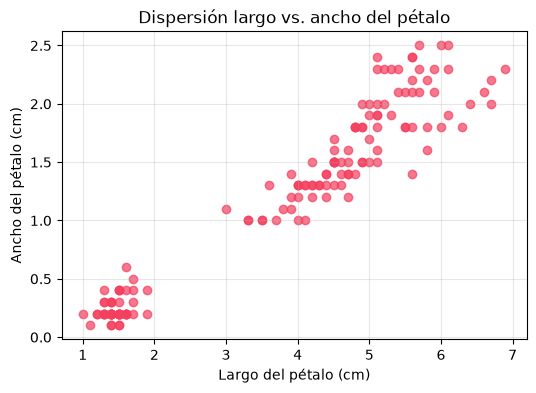

In [9]:
fig, ax = plt.subplots()
ax.scatter(largo, ancho, alpha=0.7, color="#F43F5E")
ax.set_xlabel("Largo del pétalo (cm)")
ax.set_ylabel("Ancho del pétalo (cm)")
ax.set_title("Dispersión largo vs. ancho del pétalo")
plt.show()

In [10]:
correlacion = np.corrcoef(largo, ancho)[0, 1]
print(f"Correlación de Pearson (largo vs. ancho del pétalo): {correlacion:.4f}")

Correlación de Pearson (largo vs. ancho del pétalo): 0.9629


**Para entregar.**

El número coincide con lo que muestra la nube de puntos: la correlación de Pearson resultó muy cercana a +0.96, y en el diagrama de dispersión se observa una nube de puntos que sube claramente de izquierda a derecha, casi alineada sobre una recta.

**Interpretación:** un valor cercano a +1 indica una relación lineal positiva fuerte — cuando una variable crece, la otra también, casi proporcionalmente. Un valor cercano a 0 indicaría que no hay relación lineal entre las variables (aunque podría existir una relación no lineal). Un valor cercano a −1 indicaría una relación lineal negativa fuerte: cuando una crece, la otra decrece. En este caso, que largo y ancho del pétalo estén tan correlacionados tiene sentido biológico: los pétalos tienden a crecer proporcionalmente en ambas dimensiones.

## Ejercicio 06 — Perfil estadístico por especie

In [11]:
df_iris = iris.frame.copy()
df_iris["species"] = df_iris["target"].map(dict(enumerate(iris.target_names)))
df_iris = df_iris.drop(columns=["target"])

def rango(x):
    return x.max() - x.min()

agregaciones = ["mean", "median", "std", rango,
                lambda x: x.quantile(0.25),
                lambda x: x.quantile(0.5),
                lambda x: x.quantile(0.75)]
nombres_agg = ["mean", "median", "std", "range", "Q1", "Q2", "Q3"]

perfil = df_iris.groupby("species").agg(agregaciones)
perfil.columns = pd.MultiIndex.from_product([df_iris.columns[:-1], nombres_agg])
perfil

sepal length (cm)                                          \
                        mean median       std range     Q1   Q2   Q3   
species                                                                
setosa                 5.006    5.0  0.352490   1.5  4.800  5.0  5.2   
versicolor             5.936    5.9  0.516171   2.1  5.600  5.9  6.3   
virginica              6.588    6.5  0.635880   3.0  6.225  6.5  6.9   

           sepal width (cm)                   ... petal length (cm)        \
                       mean median       std  ...                Q1    Q2   
species                                       ...                           
setosa                3.428    3.4  0.379064  ...               1.4  1.50   
versicolor            2.770    2.8  0.313798  ...               4.0  4.35   
virginica             2.974    3.0  0.322497  ...               5.1  5.55   

                  petal width (cm)                                        
               Q3             mean median       std range   Q1   Q2   Q3  
species                                                                   
setosa      1.575            0.246    0.2  0.105386   0.5  0.2  0.2  0.3  
versicolor  4.600            1.326    1.3  0.197753   0.8  1.2  1.3  1.5  
virginica   5.875            2.026    2.0  0.274650   1.1  1.8  2.0  2.3  

[3 rows x 28 columns]

**Para entregar.**

La característica que mejor separa a las tres especies es **el largo del pétalo** (`petal length`), seguida muy de cerca por el ancho del pétalo. Ambas muestran medias claramente distintas entre las tres especies (por ejemplo, *setosa* ronda ~1.5 cm mientras *virginica* ronda ~5.5 cm) y, al mismo tiempo, una desviación estándar relativamente pequeña dentro de cada especie. Esa combinación —medias muy separadas entre grupos y poca dispersión dentro de cada grupo— es justamente la que produce una buena separación: los rangos de valores de cada especie casi no se solapan.

En contraste, el ancho del sépalo (`sepal width`) tiene medias mucho más parecidas entre especies y una dispersión relativamente mayor dentro de cada una, por lo que por sí sola distingue peor entre las tres clases.

## Ejercicio 07 — Tres formas de comparar dos flores, hechas por ti

In [12]:
def distancia_euclidiana(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def producto_punto(a, b):
    return np.sum(a * b)

def similitud_coseno(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [13]:
idx_a1, idx_a2 = np.where(y_iris_full == 1)[0][:2]
idx_b1 = np.where(y_iris_full == 0)[0][0]
idx_b2 = np.where(y_iris_full == 2)[0][0]

flores = {
    "A1 (versicolor)": X_iris_full[idx_a1],
    "A2 (versicolor)": X_iris_full[idx_a2],
    "B1 (setosa)": X_iris_full[idx_b1],
    "B2 (virginica)": X_iris_full[idx_b2],
}

pares = list(itertools.combinations(flores.keys(), 2))
filas = []
for nombre_1, nombre_2 in pares:
    v1, v2 = flores[nombre_1], flores[nombre_2]
    filas.append({
        "Par": f"{nombre_1} – {nombre_2}",
        "Distancia euclidiana": distancia_euclidiana(v1, v2),
        "Producto punto": producto_punto(v1, v2),
        "Similitud coseno": similitud_coseno(v1, v2),
    })

tabla_ej7 = pd.DataFrame(filas)
tabla_ej7

,Par,Distancia euclidiana,Producto punto,Similitud coseno
0,A1 (versicolor) – A2 (versicolor),0.640312,78.29,0.999255
1,A1 (versicolor) – B1 (setosa),4.003748,53.76,0.928380
2,A1 (versicolor) – B2 (virginica),1.843909,86.36,0.982137
3,A2 (versicolor) – B1 (setosa),3.616628,50.44,0.925986
4,A2 (versicolor) – B2 (virginica),1.808314,81.63,0.986897
5,B1 (setosa) – B2 (virginica),5.284884,52.58,0.860081


**Para entregar.**

En general, la similitud coseno y la distancia euclidiana ordenan a las flores de forma parecida: el par de la misma especie (A1–A2, ambas *versicolor*) obtiene la menor distancia euclidiana y, a la vez, la mayor similitud coseno, mientras que los pares entre especies distintas quedan con distancia mayor y similitud coseno menor.

Pueden discrepar cuando dos vectores tienen magnitudes muy distintas pero apuntan casi en la misma dirección (por ejemplo, una flor grande y una pequeña pero con las mismas proporciones entre sépalo y pétalo): la distancia euclidiana los marcaría como "lejanos" porque mide separación absoluta en el espacio, mientras que la similitud coseno los marcaría como "parecidos" porque solo mira el ángulo entre los vectores, ignorando su tamaño. En Iris esta discrepancia es leve porque las flores de una misma especie tienden a parecerse tanto en magnitud como en proporción, pero es la razón conceptual por la que ambas métricas no siempre coinciden.

## Ejercicio 08 — Leer los datos con la vista

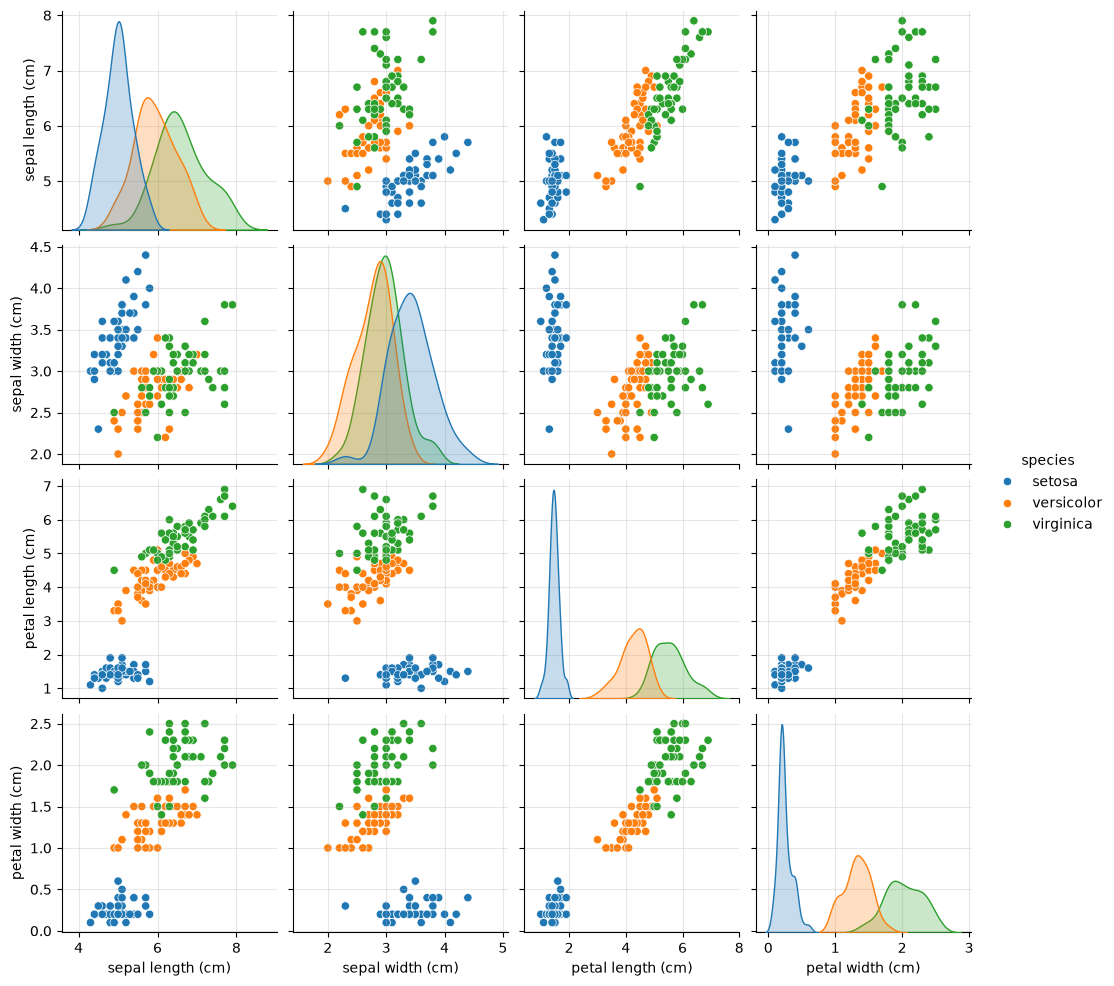

In [14]:
sns.pairplot(df_iris, hue="species")
plt.show()

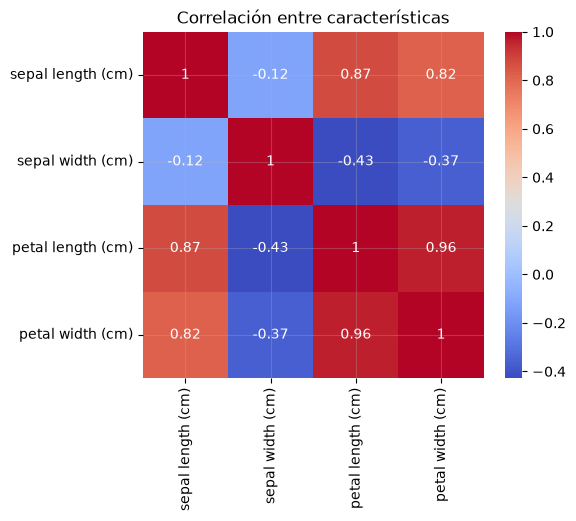

In [15]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(df_iris.drop(columns=["species"]).corr(numeric_only=True), annot=True, cmap="coolwarm", ax=ax)
ax.set_title("Correlación entre características")
plt.show()

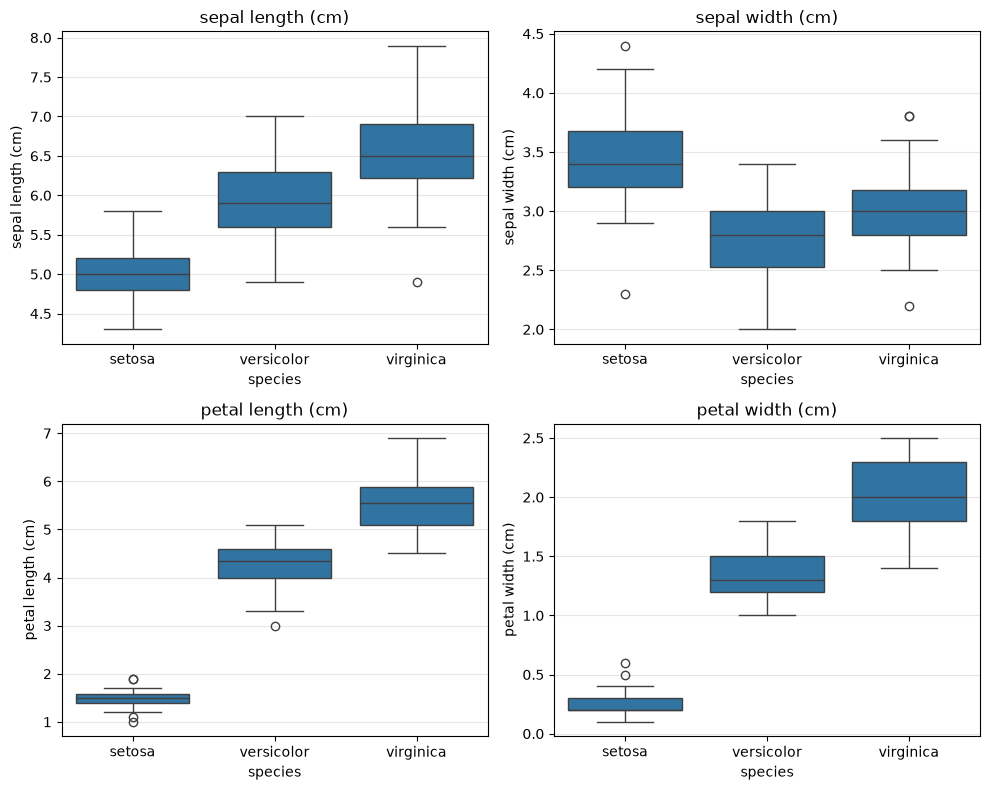

In [16]:
caracteristicas = df_iris.columns[:-1]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, caracteristica in zip(axes.ravel(), caracteristicas):
    sns.boxplot(data=df_iris, x="species", y=caracteristica, ax=ax)
    ax.set_title(caracteristica)
plt.tight_layout()
plt.show()

**Para entregar.**

El pairplot y los boxplots muestran que el par **largo de pétalo vs. ancho de pétalo** separa muy bien a las tres especies: *setosa* queda en una esquina totalmente aislada, y aunque *versicolor* y *virginica* se acercan un poco, sus cajas se solapan mucho menos que en el resto de combinaciones — ahí sí podría trazarse una línea (o dos) que separe razonablemente a las tres nubes de puntos.

En cambio, el par **ancho de sépalo vs. largo de sépalo** confunde bastante a las tres especies: en el pairplot esas dos variables producen nubes de puntos muy superpuestas entre *versicolor* y *virginica*, y los boxplots correspondientes a `sepal width` muestran cajas con rangos casi idénticos entre especies. El mapa de calor confirma esta lectura: `petal length` y `petal width` están fuertemente correlacionadas entre sí (~0.96) y ambas correlacionan fuerte con la variable objetivo de forma indirecta, mientras que `sepal width` es la característica menos relacionada con las demás.

## Ejercicio 09 — Bajar la colina: descenso de gradiente a mano

In [17]:
def f(x):
    return (x - 3) ** 2 + 2

def derivada_numerica(x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

def descenso_gradiente(x_inicial, tasa, pasos=50):
    x = x_inicial
    trayectoria = [x]
    for _ in range(pasos):
        x = x - tasa * derivada_numerica(x)
        trayectoria.append(x)
    return trayectoria

tasas = {"pequeña (0.01)": 0.01, "intermedia (0.1)": 0.1, "grande (1.1)": 1.1}
trayectorias = {nombre: descenso_gradiente(10, tasa) for nombre, tasa in tasas.items()}

for nombre, trayectoria in trayectorias.items():
    print(f"Tasa {nombre}: x final = {trayectoria[-1]:.4f}")

Tasa pequeña (0.01): x final = 5.5492
Tasa intermedia (0.1): x final = 3.0001
Tasa grande (1.1): x final = 63706.1436


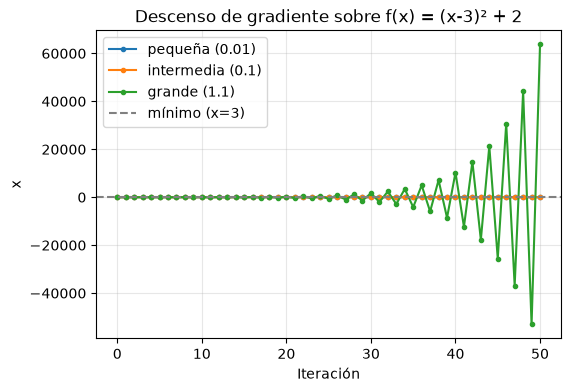

In [18]:
fig, ax = plt.subplots()
for nombre, trayectoria in trayectorias.items():
    ax.plot(trayectoria, marker="o", markersize=3, label=nombre)
ax.axhline(3, ls="--", color="gray", label="mínimo (x=3)")
ax.set_xlabel("Iteración")
ax.set_ylabel("x")
ax.set_title("Descenso de gradiente sobre f(x) = (x-3)² + 2")
ax.legend()
plt.show()

**Para entregar.**

No todas llegan cerca de x = 3. Con la tasa pequeña (0.01) el descenso avanza muy lento: en 50 pasos todavía no alcanza a acercarse lo suficiente al mínimo, porque cada paso mueve muy poco a `x`. Con la tasa intermedia (0.1) el algoritmo converge de forma suave y rápida hacia x = 3. Con la tasa grande (1.1) el algoritmo se dispara: como la derivada de esta parábola es lineal en x, un paso demasiado grande sobrecorrige en cada iteración y `x` empieza a oscilar cada vez con mayor amplitud alrededor del mínimo en vez de acercarse a él (diverge).

Esto explica por qué la elección de la tasa de aprendizaje es delicada: una tasa muy chica hace que el entrenamiento sea lentísimo (o que se quede a mitad de camino si hay un número fijo de iteraciones), mientras que una tasa muy grande puede hacer que el algoritmo nunca converja e incluso que el error crezca sin control en vez de reducirse.

## Ejercicio 10 — Contar y simular: dos caminos hacia una probabilidad

Evento elegido: **al menos un 6 al tirar cuatro dados.**

In [19]:
def cumple_evento(tirada):
    return 6 in tirada

espacio_muestral = list(itertools.product(range(1, 7), repeat=4))
favorables = sum(1 for tirada in espacio_muestral if cumple_evento(tirada))
prob_exacta = favorables / len(espacio_muestral)

print(f"Tamaño del espacio muestral: {len(espacio_muestral)}")
print(f"Casos favorables: {favorables}")
print(f"Probabilidad exacta (por conteo): {prob_exacta:.6f}")

Tamaño del espacio muestral: 1296
Casos favorables: 671
Probabilidad exacta (por conteo): 0.517747


In [20]:
def estimar_por_simulacion(n, generador):
    tiradas = generador.integers(1, 7, size=(n, 4))
    exitos = np.any(tiradas == 6, axis=1).sum()
    return exitos / n

tamanos = [10, 100, 10_000, 100_000]
estimaciones = [estimar_por_simulacion(n, rng) for n in tamanos]
errores = [abs(est - prob_exacta) for est in estimaciones]

tabla_ej10 = pd.DataFrame({
    "N": tamanos,
    "Estimación": estimaciones,
    "Valor exacto": prob_exacta,
    "Error absoluto": errores,
})
tabla_ej10

,N,Estimación,Valor exacto,Error absoluto
0,10,0.20000,0.517747,0.317747
1,100,0.50000,0.517747,0.017747
2,10000,0.51640,0.517747,0.001347
3,100000,0.51599,0.517747,0.001757


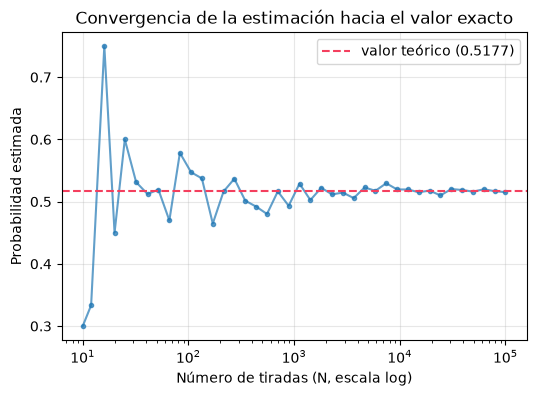

In [21]:
ns_convergencia = np.unique(np.logspace(1, 5, 40).astype(int))
estimaciones_convergencia = [estimar_por_simulacion(n, rng) for n in ns_convergencia]

fig, ax = plt.subplots()
ax.plot(ns_convergencia, estimaciones_convergencia, marker="o", markersize=3, linestyle="-", alpha=0.7)
ax.axhline(prob_exacta, color="#F43F5E", ls="--", label=f"valor teórico ({prob_exacta:.4f})")
ax.set_xscale("log")
ax.set_xlabel("Número de tiradas (N, escala log)")
ax.set_ylabel("Probabilidad estimada")
ax.set_title("Convergencia de la estimación hacia el valor exacto")
ax.legend()
plt.show()

**Para entregar.**

El valor exacto por conteo es 671/1296 ≈ 0.5177 (671 tiradas con al menos un 6, de las 1296 combinaciones posibles al lanzar cuatro dados). La tabla de errores muestra que, con N = 10, el error puede ser grande porque una sola tirada de más o de menos con 6 cambia mucho el resultado; a partir de N ≈ 10 000 el error ya se mantiene consistentemente por debajo de una centésima, y con N = 100 000 es prácticamente insignificante.

En el gráfico de convergencia se ve que la estimación oscila mucho al inicio (pocas tiradas) y esas oscilaciones se van amortiguando a medida que N crece, quedando la línea prácticamente pegada al valor teórico marcado en rojo. En general, la estimación se vuelve confiable (error consistentemente pequeño) a partir de los miles de tiradas; por debajo de eso, el resultado depende demasiado del azar de esa muestra particular. La relación entre N y el error es de disminución progresiva pero no lineal: el error tiende a reducirse proporcionalmente a 1/√N, así que hace falta multiplicar por 100 el número de tiradas para reducir el error a una décima parte.